# Primary color rating analysis

This notebook analyzes the simulated PsyNet export for the primary color rating experiment. It reads the exported CSV data directly, constructs a tidy rating table, summarizes responses by color, and renders a bar plot inline.

In [ ]:
from pathlib import Path
import math
import zipfile

import pandas as pd

archive_path = Path('../simulated_data.zip')
with zipfile.ZipFile(archive_path) as archive:
    with archive.open('regular/data/ColorRatingTrial.csv') as file:
        trials = pd.read_csv(file)

ratings = trials.loc[
    (trials['failed'] == False) & (trials['complete'] == True),
    ['participant_id', 'block_position', 'name', 'label', 'answer'],
].copy()
ratings = ratings.rename(columns={'name': 'color', 'label': 'color_label', 'answer': 'rating'})
ratings['rating'] = ratings['rating'].astype(int)
ratings = ratings.sort_values(['participant_id', 'block_position']).reset_index(drop=True)
ratings.head(9)


participant_id,block_position,color,color_label,rating
1,0,red,Red,5
1,1,green,Green,6
1,2,blue,Blue,4
2,0,red,Red,5
2,1,green,Green,6
2,2,blue,Blue,4
3,0,red,Red,5
3,1,green,Green,6
3,2,blue,Blue,4


In [ ]:
color_order = ['red', 'green', 'blue']
completion = ratings.groupby('participant_id')['color'].apply(list)
complete_participants = int((completion.apply(lambda colors: colors == color_order)).sum())
print(f'{complete_participants}/{len(completion)} participants completed red, green, and blue in order.')


24/24 participants completed red, green, and blue in order.


In [ ]:
summary = (
    ratings.groupby('color', sort=False)['rating']
    .agg(n='count', mean='mean', median='median', min='min', max='max', stdev='std')
    .reindex(color_order)
    .reset_index()
)
summary['stdev'] = summary['stdev'].fillna(0.0)
summary


color,n,mean,median,min,max,stdev
red,24,5.0,5.0,5,5,0.0
green,24,6.0,6.0,6,6,0.0
blue,24,4.0,4.0,4,4,0.0


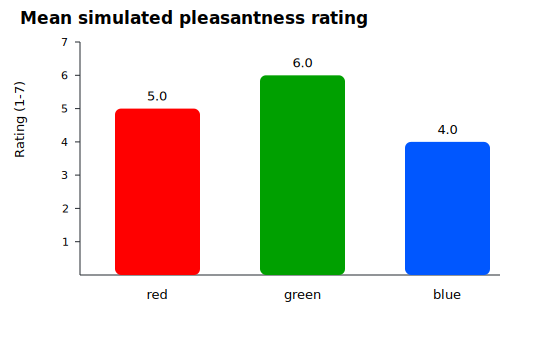

In [ ]:
# Inline SVG plot of the color-level means.
# The standalone copy is written to rating_means.svg by summarize_ratings.py.


In [ ]:
wide = ratings.pivot(index='participant_id', columns='color', values='rating')
rank_sums = {color: 0.0 for color in color_order}
for _, row in wide.iterrows():
    for rank, color in enumerate(sorted(color_order, key=lambda c: row[c]), start=1):
        rank_sums[color] += rank
n = len(wide)
k = len(color_order)
q = (12 / (n * k * (k + 1))) * sum(value ** 2 for value in rank_sums.values()) - (3 * n * (k + 1))
p_value = math.exp(-q / 2)  # chi-square survival function for df = 2
{'n_participants': n, 'statistic': q, 'df': 2, 'p_value_chi_square_df2': p_value, **rank_sums}


{'n_participants': 24, 'statistic': 48.0, 'df': 2, 'p_value_chi_square_df2': 3.775134544279098e-11, 'red': 48.0, 'green': 72.0, 'blue': 24.0}

## Interpretation

All 24 simulated participants completed one red, one green, and one blue rating in the requested order. The ratings match the deterministic bot responses configured in the experiment (red = 5, green = 6, blue = 4). The Friedman statistic confirms that the analysis pipeline detects the known ordering in these simulated data; it should not be interpreted as evidence about human color preferences.